# Assignment 2 - Data Preparation and Analysis

**Developer:** Julia Sveen, BSIT

**Course:** Artificial Intelligence Applications

**Program Requirements (data analysis and visualization steps):**

    1. Get
    2. Clean
    3. Prepare
    4. Analyze
    5. Visualize

**Note:** In each of the following examples, **BE SURE** to research the functions/properties/options indicated.

In [1]:
# 1. import necessary modules
import sys
import os
import pandas as pd
print(sys.version) # print python version
print(os.environ['CONDA_DEFAULT_ENV']) # print conda environment

3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
base


## Get Data

In [2]:
# 2. get mortality data: National Cetner for Health Stats
    # https://data.cdc.gov/NCHS/NCHS-Childhood-Mortality-Rates/v6ab-adf5
mortality_url="https://data.cdc.gov/api/views/v6ab-adf5/rows.csv"

In [3]:
# 3. read csv into df
mortality_data = pd.read_csv(mortality_url)

# Assistant
This error occurs when pandas is having trouble parsing the CSV file correctly. The error message indicates that pandas expected 1 field in line 21 but found 251 fields instead. This typically happens when the delimiter (separator) in the CSV file is not what pandas is expecting by default (which is a comma).

The issue could be:
1. The file might be using a different delimiter (like tab, semicolon, etc.)
2. There might be inconsistent formatting in the file
3. The file might need additional parameters to be parsed correctly

Would you like me to provide the corrected code?

## Save DataFrame to Pickle File

In [4]:
# 4. save DF to pickle
mortality_data.to_pickle('mortality_data.pkl')

In [5]:
# 5. read pickle file
    # note: below, data in mortality_data var changed from csv to pickle data
mortality_data = pd.read_pickle('mortality_data.pkl')

## (First - examine, then...), clean, prepare, analyze, and display data

### Cleaning

**Note:** Generally, the following items are done during "cleaning" process

    1. Drop duplicate rows
    2. Drop rows and columns not needed
    3. Rename columns

In [6]:
# 6. display first and last five rows with one command
# mortality_data # note: only works in Jupyter notebooks
print(mortality_data)

     Year    Age Group  Death Rate
0    1900    1-4 Years      1983.8
1    1901    1-4 Years      1695.0
2    1902    1-4 Years      1655.7
3    1903    1-4 Years      1542.1
4    1904    1-4 Years      1591.5
..    ...          ...         ...
471  2014  15-19 Years        45.5
472  2015  15-19 Years        48.3
473  2016  15-19 Years        51.2
474  2017  15-19 Years        51.5
475  2018  15-19 Years        49.2

[476 rows x 3 columns]


In [7]:
# 7. first 5 rows only
print(mortality_data.head())

   Year  Age Group  Death Rate
0  1900  1-4 Years      1983.8
1  1901  1-4 Years      1695.0
2  1902  1-4 Years      1655.7
3  1903  1-4 Years      1542.1
4  1904  1-4 Years      1591.5


In [8]:
# 8. last 3 rows only
mortality_data.tail(3)

,Year,Age Group,Death Rate
473,2016,15-19 Years,51.2
474,2017,15-19 Years,51.5
475,2018,15-19 Years,49.2


In [9]:
# 9. using pandas option_context() func, display 6 rows (first & last 3) and all cols
    # note: option_context() - executes codeblock with set of options that revert to prior settings after exec
    # note: 'none' value for 'display.max_columns' properly returns all cols
with pd.option_context(
    'display.max_rows', 6,
    'display.max_columns', None):
    print(mortality_data)

     Year    Age Group  Death Rate
0    1900    1-4 Years      1983.8
1    1901    1-4 Years      1695.0
2    1902    1-4 Years      1655.7
..    ...          ...         ...
473  2016  15-19 Years        51.2
474  2017  15-19 Years        51.5
475  2018  15-19 Years        49.2

[476 rows x 3 columns]


## Display DataFrame Attributes

In [10]:
# 10. print following df attributes: index, columns, size and shape
print("Index: ",mortality_data.index)
print("Columnns: ",mortality_data.columns)
print("Size: ",mortality_data.size)
print("Shape: ",mortality_data.shape)

Index:  RangeIndex(start=0, stop=476, step=1)
Columnns:  Index(['Year', 'Age Group', 'Death Rate'], dtype='object')
Size:  1428
Shape:  (476, 3)


In [11]:
# 11. display df values in arr
print(mortality_data.values)

[[1900 '1-4 Years' 1983.8]
 [1901 '1-4 Years' 1695.0]
 [1902 '1-4 Years' 1655.7]
 ...
 [2016 '15-19 Years' 51.2]
 [2017 '15-19 Years' 51.5]
 [2018 '15-19 Years' 49.2]]


## Use Columns Attribute to Change Column Names (Ex: Remove any Spaces)

In [12]:
# 12. use columns attribute, replace() func to remove spaces in column names
mortality_data.columns = mortality_data.columns.str.replace(" ","")

In [13]:
# 13. print column names
print(mortality_data.columns)

Index(['Year', 'AgeGroup', 'DeathRate'], dtype='object')


In [14]:
# 14. print column names with first 5 records
print(mortality_data.head())

   Year   AgeGroup  DeathRate
0  1900  1-4 Years     1983.8
1  1901  1-4 Years     1695.0
2  1902  1-4 Years     1655.7
3  1903  1-4 Years     1542.1
4  1904  1-4 Years     1591.5


## Use info(), nunique(), describe() Methods

In [15]:
# 15. print df info
mortality_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476 entries, 0 to 475
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       476 non-null    int64  
 1   AgeGroup   476 non-null    object 
 2   DeathRate  476 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 11.3+ KB


In [16]:
# 16. print df info, including accurate mem usage
mortality_data.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476 entries, 0 to 475
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       476 non-null    int64  
 1   AgeGroup   476 non-null    object 
 2   DeathRate  476 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 35.0 KB


In [17]:
# 17. summarize unique values (ex: no duplicates) in each column
mortality_data.nunique()

Year         119
AgeGroup       4
DeathRate    430
dtype: int64

In [18]:
# 18. display generic stats for each numeric column - using describe() func
mortality_data.describe()

,Year,DeathRate
count,476.000000,476.000000
mean,1959.000000,192.924160
std,34.387268,293.224216
min,1900.000000,11.400000
25%,1929.000000,40.575000
50%,1959.000000,89.500000
75%,1989.000000,222.575000
max,2018.000000,1983.800000


In [19]:
# 19. transpose stats so names are displayed in columns (using T properly)
mortality_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,476.0,1959.00000,34.387268,1900.0,1929.000,1959.0,1989.000,2018.0
DeathRate,476.0,192.92416,293.224216,11.4,40.575,89.5,222.575,1983.8


In [20]:
# 20. save cleaned df to pickle file (mortality_cleaned.pkl)
mortality_data.to_pickle('mortality_cleaned.pkl')

In [21]:
# 21. read cleaned pickle file to mortality_data variable
mortality_data = pd.read_pickle('mortality_cleaned.pkl')

In [22]:
# 22. display first 5 rows of cleaned pickle file
print(mortality_data.head())

   Year   AgeGroup  DeathRate
0  1900  1-4 Years     1983.8
1  1901  1-4 Years     1695.0
2  1902  1-4 Years     1655.7
3  1903  1-4 Years     1542.1
4  1904  1-4 Years     1591.5


## Accessing Data

### Access Data (Columns)

In [23]:
# using dot notation
    # note: can't use dot notation w/multiple columns or w/spaces
# 23. display first 2 records of DeathRate column using dot notation
print(mortality_data.DeathRate.head(2))

0    1983.8
1    1695.0
Name: DeathRate, dtype: float64


In [24]:
# 24. same as above using single brackets
print(mortality_data['DeathRate'].head(2))

0    1983.8
1    1695.0
Name: DeathRate, dtype: float64


In [25]:
# 25. same as above, using double brackets
print(mortality_data[['DeathRate']].head(2))

   DeathRate
0     1983.8
1     1695.0


In [26]:
# note the difference in types
# 26. display DeathRate type using dot notation
# note type (series)
print(type(mortality_data.DeathRate))

<class 'pandas.core.series.Series'>


In [27]:
# 27. type with single brackets
print(type(mortality_data['DeathRate']))

<class 'pandas.core.series.Series'>


In [28]:
# 28. type with double brackets
    # note: type with double brackets is df
print(type(mortality_data[['DeathRate']]))

<class 'pandas.core.frame.DataFrame'>


In [29]:
# 29. access more than one column, must use brackets
print(mortality_data[['Year','DeathRate']].head(2))

   Year  DeathRate
0  1900     1983.8
1  1901     1695.0


In [30]:
# 30. display Year and DeathRate type using double brackets
    # note the type: df
type(mortality_data[['Year','DeathRate']])

pandas.core.frame.DataFrame

## Accessing Rows

In [31]:
# 31. access data using query() func (Year=1900)
print(mortality_data.query('Year==1900'))

     Year     AgeGroup  DeathRate
0    1900    1-4 Years     1983.8
119  1900    5-9 Years      466.1
238  1900  10-14 Years      298.3
357  1900  15-19 Years      484.8


In [32]:
# 32. Access data using query() func (Year=2000 and AgeGroup!=1-4 Years)
print(mortality_data.query('Year == 2000 and AgeGroup != "1-4 Years"'))

     Year     AgeGroup  DeathRate
219  2000    5-9 Years       15.8
338  2000  10-14 Years       20.3
457  2000  15-19 Years       67.1


In [33]:
# 33. Access data using query() func (Year=1900 or 2000), display first 5 records
print(mortality_data.query('Year == 1900 or Year == 2000').head())

     Year     AgeGroup  DeathRate
0    1900    1-4 Years     1983.8
100  2000    1-4 Years       32.4
119  1900    5-9 Years      466.1
219  2000    5-9 Years       15.8
238  1900  10-14 Years      298.3


In [34]:
## Access Subset of Rows and Columns

In [35]:
# note: use backticks if column has spaces
# 34. using dot notation, access data using query() func (Year = 1900), only for DeathRate column, display first 5 records
print(mortality_data.query('Year == 1900').DeathRate.head())

0      1983.8
119     466.1
238     298.3
357     484.8
Name: DeathRate, dtype: float64


In [36]:
# 35. using single bracket notation, access data using query() func (Year=1900), only for DeathRate column, display first 5 records
print(mortality_data.query('Year == 1900')['DeathRate'].head())

0      1983.8
119     466.1
238     298.3
357     484.8
Name: DeathRate, dtype: float64


In [37]:
# 36. using double bracket notation, access data using query() func (Year=1900), only for DeathRate column, display first 5 records
print(mortality_data.query('Year==1900')[['DeathRate']].head())

     DeathRate
0       1983.8
119      466.1
238      298.3
357      484.8


In [38]:
# 37. display data type of dot notation used above
print(type(mortality_data.query('Year==1900')['DeathRate'].head()))

<class 'pandas.core.series.Series'>


In [39]:
# 38. display data type of single bracket notation used above
print(type(mortality_data.query('Year==1900')['DeathRate'].head()))

<class 'pandas.core.series.Series'>


In [40]:
# 39. display data type of double bracket notation used above 
print(type(mortality_data.query('Year == 1900')[['DeathRate']].head()))

<class 'pandas.core.frame.DataFrame'>


In [41]:
# 40. using double bracket notation, access data using query() function (Year==1900), AgeGroup, DeathRate, display first 5 records
print(mortality_data.query('Year == 1900')[['AgeGroup','DeathRate']].head())

        AgeGroup  DeathRate
0      1-4 Years     1983.8
119    5-9 Years      466.1
238  10-14 Years      298.3
357  15-19 Years      484.8


## Access Rows with Loc[] Accessor

In [42]:
# 41. display row values for 0, 5, and 10 index 'labels'
mortality_data.loc[[0,5,10]]

,Year,AgeGroup,DeathRate
0,1900,1-4 Years,1983.8
5,1905,1-4 Years,1498.9
10,1910,1-4 Years,1397.3


In [43]:
# 42. verify index 'labels' and row values
mortality_data.head(11)

,Year,AgeGroup,DeathRate
0,1900,1-4 Years,1983.8
1,1901,1-4 Years,1695.0
2,1902,1-4 Years,1655.7
3,1903,1-4 Years,1542.1
4,1904,1-4 Years,1591.5
5,1905,1-4 Years,1498.9
6,1906,1-4 Years,1580.0
7,1907,1-4 Years,1468.3
8,1908,1-4 Years,1396.8
9,1909,1-4 Years,1348.9


In [44]:
# 43. access rows using slice
mortality_data.loc[4:6]

,Year,AgeGroup,DeathRate
4,1904,1-4 Years,1591.5
5,1905,1-4 Years,1498.9
6,1906,1-4 Years,1580.0


In [45]:
# 44. access rows using slice, include start, stop and step values
mortality_data.loc[0:20:5]

,Year,AgeGroup,DeathRate
0,1900,1-4 Years,1983.8
5,1905,1-4 Years,1498.9
10,1910,1-4 Years,1397.3
15,1915,1-4 Years,924.2
20,1920,1-4 Years,987.2


In [46]:
# 45. access rows using conditional expression (Year=1917)
mortality_data.loc[mortality_data.Year == 1917]

,Year,AgeGroup,DeathRate
17,1917,1-4 Years,1066.0
136,1917,5-9 Years,290.7
255,1917,10-14 Years,218.9
374,1917,15-19 Years,380.3


## Access Rows and Columns with Loc[] Accessor

In [47]:
# 46. display first and last 5 rows
mortality_data.loc[:,['Year','AgeGroup']]

,Year,AgeGroup
0,1900,1-4 Years
1,1901,1-4 Years
2,1902,1-4 Years
3,1903,1-4 Years
4,1904,1-4 Years
...,...,...
471,2014,15-19 Years
472,2015,15-19 Years
473,2016,15-19 Years
474,2017,15-19 Years


## Access Subset of Rows and Columns with Loc[] Accessor

In [48]:
# 47. using loc[] accessor with lists for row and column labels, display row values for 0, 5, 10 index 'labels'
mortality_data.loc[[0,5,10],['AgeGroup','DeathRate']]

,AgeGroup,DeathRate
0,1-4 Years,1983.8
5,1-4 Years,1498.9
10,1-4 Years,1397.3


In [49]:
# 48. using slices of rows and column labels
mortality_data.loc[4:6,'AgeGroup':'DeathRate']

,AgeGroup,DeathRate
4,1-4 Years,1591.5
5,1-4 Years,1498.9
6,1-4 Years,1580.0


## Access Rows with ILoc[] Accessor

In [50]:
# 49. display first, sixth and 11th rows
mortality_data.iloc[[0,5,10]]

,Year,AgeGroup,DeathRate
0,1900,1-4 Years,1983.8
5,1905,1-4 Years,1498.9
10,1910,1-4 Years,1397.3


In [51]:
# 50. verify index positions and row values
mortality_data.head(11)

,Year,AgeGroup,DeathRate
0,1900,1-4 Years,1983.8
1,1901,1-4 Years,1695.0
2,1902,1-4 Years,1655.7
3,1903,1-4 Years,1542.1
4,1904,1-4 Years,1591.5
5,1905,1-4 Years,1498.9
6,1906,1-4 Years,1580.0
7,1907,1-4 Years,1468.3
8,1908,1-4 Years,1396.8
9,1909,1-4 Years,1348.9


In [52]:
# 51. access rows using slice
mortality_data.iloc[4:6]

,Year,AgeGroup,DeathRate
4,1904,1-4 Years,1591.5
5,1905,1-4 Years,1498.9


In [53]:
# 52. access rows using slice, include start, stop and step values
mortality_data.iloc[0:20:5]

,Year,AgeGroup,DeathRate
0,1900,1-4 Years,1983.8
5,1905,1-4 Years,1498.9
10,1910,1-4 Years,1397.3
15,1915,1-4 Years,924.2


## Access Subset of Rows and Columns with ILoc[] Accessor, Can Use Negative Values

In [54]:
# 53. display rows and columns using index positions and lists
mortality_data.iloc[[0,5,10],[1,2]]

,AgeGroup,DeathRate
0,1-4 Years,1983.8
5,1-4 Years,1498.9
10,1-4 Years,1397.3


In [55]:
# 54. display rows and columns using index positions and slices
mortality_data.iloc[4:7,1:3]

,AgeGroup,DeathRate
4,1-4 Years,1591.5
5,1-4 Years,1498.9
6,1-4 Years,1580.0


In [56]:
# 55. use iloc[] accessor with negative value
mortality_data.iloc[-10:]

,Year,AgeGroup,DeathRate
466,2009,15-19 Years,51.9
467,2010,15-19 Years,49.4
468,2011,15-19 Years,48.9
469,2012,15-19 Years,47.2
470,2013,15-19 Years,44.8
471,2014,15-19 Years,45.5
472,2015,15-19 Years,48.3
473,2016,15-19 Years,51.2
474,2017,15-19 Years,51.5
475,2018,15-19 Years,49.2


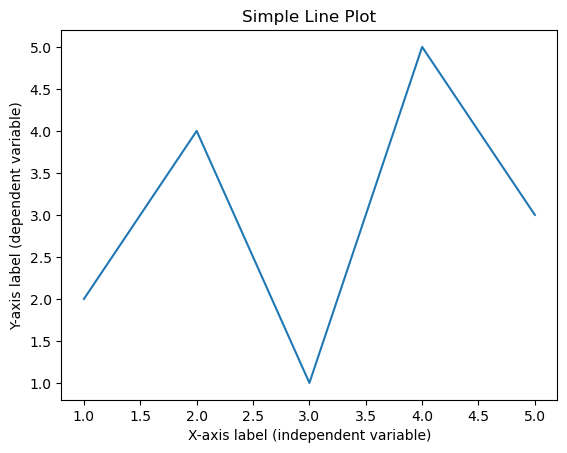

In [57]:
# 56. simple visualization demo
import matplotlib.pyplot as plt
import numpy as np
# sample data
x = np.array([1,2,3,4,5])
y = np.array([2,4,1,5,3])
# create plot
plt.plot(x,y)
# add labels and title
plt.xlabel("X-axis label (independent variable)")
plt.ylabel("Y-axis label (dependent variable)")
plt.title("Simple Line Plot")
# display plot
plt.show()